# County Processed Data EDA

Dataset: `data/20260401_county_processed_data/county_processed_data.feather`

This notebook performs exploratory data analysis for structure, completeness, date coverage, geographic coverage, and high-signal distributions. Run cells from top to bottom after installing the project dependencies.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent


DATA_PATH = ROOT / "data" / "20260401_county_processed_data" / "county_processed_data.feather"
DATA_PATH

WindowsPath('C:/Users/kenny/Data Science Projects/quoll-intelligence/data/20260401_county_processed_data/county_processed_data.feather')

## Load And Inspect

In [2]:
df = pd.read_feather(DATA_PATH)
display(df.head())
display(df.shape)
display(df.dtypes.to_frame("dtype"))

,index,fips,county_name,state,state_long,msa_code,msa_name,msa_type,csa_code,csa_name,has_redfin_data,state_id,metrics,nfip_claims,property_tax,insurance_premiums_14_to_24,insurance_non_renewal_rates,nri_climate,temp_max_min,fema_disaster_declarations,storm_events
0,0,01001,Autauga County,AL,Alabama,C3386,"Montgomery, AL",Metro,None,None,True,01,"{'AVG_SALE_TO_LIST': [0.973, 0.97, 0.987, 0.98...","{'amountPaidOnBuildingClaim': [0.0, 219564.44,...",{'effective_tax_rate_2024': {'percentiles': {'...,"{'averages': {'end_year': 2024, 'mean': 1652.1...","{'averages': {'end_year': 2023, 'non_renewal_r...","{'AGRIVALUE': 27630646.0, 'AREA': 610.4705, 'B...","[{'month': 1, 'tmax_average_temp_c': 16.38, 't...","{'breakdown': {'coastal_storm': [0, 0, 0], 'ea...","[{'state_id': '01', 'total_damage_crops': 0, '..."
1,1,01003,Baldwin County,AL,Alabama,C1930,"Daphne-Fairhope-Foley, AL",Metro,CS380,"Mobile-Daphne-Fairhope, AL",True,01,"{'AVG_SALE_TO_LIST': [0.975, 0.977, 0.978, 0.9...","{'amountPaidOnBuildingClaim': [62513871.14, 10...",{'effective_tax_rate_2024': {'percentiles': {'...,"{'averages': {'end_year': 2024, 'mean': 2622.1...","{'averages': {'end_year': 2023, 'non_renewal_r...","{'AGRIVALUE': 155012958.0, 'AREA': 2047.7388, ...","[{'month': 1, 'tmax_average_temp_c': 18.16, 't...","{'breakdown': {'coastal_storm': [0, 0, 0, 0], ...","[{'state_id': '01', 'total_damage_crops': 0, '..."
2,2,01005,Barbour County,AL,Alabama,None,None,None,None,None,True,01,"{'AVG_SALE_TO_LIST': [0.929, 0.93, 0.947, 0.95...","{'amountPaidOnBuildingClaim': [6277.93, 478731...",{'effective_tax_rate_2024': {'percentiles': {'...,"{'averages': {'end_year': 2024, 'mean': 1815.2...","{'averages': {'end_year': 2023, 'non_renewal_r...","{'AGRIVALUE': 135914589.0, 'AREA': 913.6465, '...","[{'month': 1, 'tmax_average_temp_c': 16.84, 't...","{'breakdown': {'coastal_storm': [0, 0, 0, 0], ...","[{'state_id': '01', 'total_damage_crops': 0, '..."
3,3,01007,Bibb County,AL,Alabama,C1382,"Birmingham-Hoover, AL",Metro,CS142,"Birmingham-Hoover-Talladega, AL",True,01,"{'AVG_SALE_TO_LIST': [0.985, 1.039, 0.945, 0.9...","{'amountPaidOnBuildingClaim': [2651.29, 1703.8...",{'effective_tax_rate_2024': {'percentiles': {'...,"{'averages': {'end_year': 2024, 'mean': 1792.7...","{'averages': {'end_year': 2023, 'non_renewal_r...","{'AGRIVALUE': 5410008.0, 'AREA': 632.4868, 'BU...","[{'month': 1, 'tmax_average_temp_c': 15.05, 't...","{'breakdown': {'coastal_storm': [0, 0], 'earth...","[{'state_id': '01', 'total_damage_crops': 0, '..."
4,4,01009,Blount County,AL,Alabama,C1382,"Birmingham-Hoover, AL",Metro,CS142,"Birmingham-Hoover-Talladega, AL",True,01,"{'AVG_SALE_TO_LIST': [0.958, 0.997, 0.967, 0.9...","{'amountPaidOnBuildingClaim': [0.0, 26760.18, ...",{'effective_tax_rate_2024': {'percentiles': {'...,"{'averages': {'end_year': 2024, 'mean': 1811.0...","{'averages': {'end_year': 2023, 'non_renewal_r...","{'AGRIVALUE': 312712010.0, 'AREA': 657.1966, '...","[{'month': 1, 'tmax_average_temp_c': 13.55, 't...","{'breakdown': {'coastal_storm': [0, 0], 'earth...","[{'state_id': '01', 'total_damage_crops': 0, '..."


(3169, 21)

,dtype
index,int64
fips,object
county_name,object
state,object
state_long,object
msa_code,object
msa_name,object
msa_type,object
csa_code,object
csa_name,object


## Completeness And Identifiers

In [3]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum()
    unique_values = []
    for col in frame.columns:
        try:
            unique_values.append(frame[col].nunique(dropna=True))
        except TypeError:
            unique_values.append(np.nan)
    return (
        pd.DataFrame({
            "missing_count": missing,
            "missing_pct": missing / len(frame) * 100,
            "dtype": frame.dtypes.astype(str),
            "unique_values": unique_values,
        })
        .sort_values("missing_pct", ascending=False)
    )


missing_summary(df).head(30)

,missing_count,missing_pct,dtype,unique_values
csa_code,2019,63.710950,object,166.0
csa_name,2019,63.710950,object,166.0
temp_max_min,1572,49.605554,object,NaN
msa_code,1362,42.978858,object,917.0
msa_name,1362,42.978858,object,917.0
msa_type,1362,42.978858,object,2.0
fema_disaster_declarations,729,23.004102,object,NaN
nfip_claims,392,12.369833,object,NaN
insurance_premiums_14_to_24,296,9.340486,object,NaN
metrics,86,2.713790,object,NaN


In [4]:
id_cols = [c for c in ["fips", "county_name", "state", "state_long", "msa_code", "msa_name"] if c in df.columns]
pd.DataFrame({
    "column": id_cols,
    "unique_values": [df[c].nunique(dropna=True) for c in id_cols],
    "missing_pct": [df[c].isna().mean() * 100 for c in id_cols],
})

,column,unique_values,missing_pct
0,fips,3169,0.000000
1,county_name,1899,0.000000
2,state,51,0.000000
3,state_long,51,0.000000
4,msa_code,917,42.978858
5,msa_name,917,42.978858


## Geographic Coverage

,counties
state,
TX,254
GA,160
VA,136
KY,120
MO,116
KS,105
IL,102
NC,100
IA,99


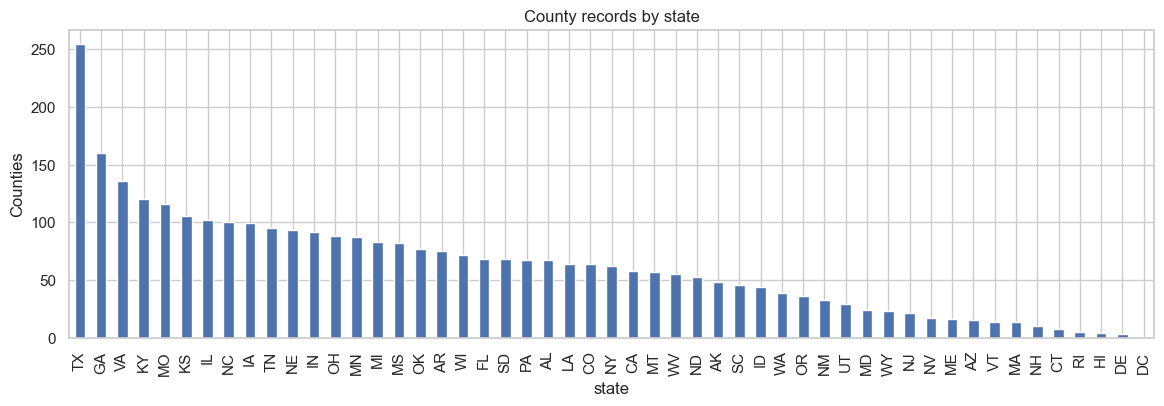

In [5]:
state_counts = df["state"].value_counts().sort_values(ascending=False)
display(state_counts.to_frame("counties"))
ax = state_counts.plot(kind="bar", figsize=(14, 4), title="County records by state")
ax.set_ylabel("Counties")
plt.show()

## Nested Data Availability

In [6]:
nested_cols = [
    "metrics", "nfip_claims", "property_tax", "insurance_premiums_14_to_24",
    "insurance_non_renewal_rates", "nri_climate", "temp_max_min",
    "fema_disaster_declarations", "storm_events",
]
nested_cols = [c for c in nested_cols if c in df.columns]

def is_non_empty_nested(value) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and pd.isna(value):
        return False
    if isinstance(value, dict):
        return len(value) > 0
    if isinstance(value, (list, tuple, set)):
        return len(value) > 0
    if hasattr(value, "shape") and hasattr(value, "size"):
        return value.size > 0
    try:
        return bool(pd.notna(value))
    except (TypeError, ValueError):
        return True

availability = []
for col in nested_cols:
    non_null = df[col].notna()
    non_empty = df[col].map(is_non_empty_nested)
    availability.append({
        "column": col,
        "non_null_count": int(non_null.sum()),
        "non_null_pct": non_null.mean() * 100,
        "non_empty_count": int(non_empty.sum()),
        "example_type": type(df.loc[non_null, col].iloc[0]).__name__ if non_null.any() else None,
    })
pd.DataFrame(availability).sort_values("non_null_pct", ascending=False)

,column,non_null_count,non_null_pct,non_empty_count,example_type
2,property_tax,3134,98.895551,3134,dict
5,nri_climate,3134,98.895551,3134,dict
8,storm_events,3115,98.295992,3115,ndarray
4,insurance_non_renewal_rates,3113,98.232881,3113,dict
0,metrics,3083,97.286210,3083,dict
3,insurance_premiums_14_to_24,2873,90.659514,2873,dict
1,nfip_claims,2777,87.630167,2777,dict
7,fema_disaster_declarations,2440,76.995898,2440,dict
6,temp_max_min,1597,50.394446,1597,ndarray


In [7]:
for col in nested_cols:
    first = df.loc[df[col].notna(), col].head(1)
    if not first.empty:
        print(f"\n{col}: {type(first.iloc[0]).__name__}")
        display(first.iloc[0])


metrics: dict


{'AVG_SALE_TO_LIST': array([0.973, 0.97 , 0.987, 0.982, 0.985, 0.982, 0.981, 0.985, 0.98 ,
        0.983, 0.99 , 0.984, 0.984, 0.978, 0.988, 0.992, 1.   , 0.999,
        0.993, 0.997, 0.996, 0.999, 0.996, 1.002, 0.993, 0.995, 1.006,
        1.003, 0.993, 1.003, 0.992, 0.995, 1.   , 0.988, 0.989, 0.992,
        0.984, 0.996, 0.989, 0.997, 0.992, 0.998, 0.996, 0.996, 0.982,
        0.991, 0.989, 0.964, 0.994, 0.995, 0.99 , 0.995, 0.992, 0.987,
        0.99 , 0.994, 0.99 , 0.987, 0.982, 0.979, 0.99 , 0.98 , 0.979,
        0.984, 0.99 , 0.982, 0.993, 0.983, 0.982, 0.984, 0.979, 0.984,
        0.983]),
 'AVG_SALE_TO_LIST_MOM': array([-0.012, -0.003,  0.017, -0.005,  0.003, -0.003, -0.001,  0.005,
        -0.005,  0.003,  0.008, -0.007,  0.   , -0.006,  0.011,  0.004,
         0.008, -0.001, -0.006,  0.005, -0.002,  0.003, -0.003,  0.006,
        -0.01 ,  0.002,  0.011, -0.003, -0.01 ,  0.01 , -0.011,  0.003,
         0.004, -0.012,  0.002,  0.003, -0.008,  0.012, -0.007,  0.008,
        -0.


nfip_claims: dict


{'amountPaidOnBuildingClaim': array([     0.  , 219564.44,      0.  ,      0.  ,  43792.16,  17884.4 ,
             0.  , 152264.06,      0.  ,      0.  ,  28044.34,      0.  ]),
 'amountPaidOnContentsClaim': array([    0.  , 33144.08,     0.  ,     0.  ,     0.  ,  6579.91,
            0.  , 12018.21,     0.  ,     0.  ,     0.  ,     0.  ]),
 'buildingDamageAmount': array([     0., 221387.,      0.,      0.,  44793.,  20884.,      0.,
        155474.,      0.,    948.,  29044.,      0.]),
 'buildingPropertyValue': array([     0., 972462.,      0.,      0., 385527., 166023.,      0.,
        987229.,      0.,  92418.,  38159.,      0.]),
 'buildingReplacementCost': array([      0., 1331850.,       0.,       0.,  566952.,  210457.,
              0., 1379770.,       0.,  293079.,   50954.,       0.]),
 'contentsDamageAmount': array([    0., 35648.,     0.,     0.,   781.,  8127.,     0., 19653.,
            0.,     0.,     0.,     0.]),
 'contentsPropertyValue': array([    0.,     0.,  


property_tax: dict


...

array([{'month': 1, 'tmax_average_temp_c': 16.38, 'tmax_average_temp_f': 61.48, 'tmax_max_temp_c': 23.29, 'tmax_max_temp_f': 73.92, 'tmax_median_temp_c': 16.26, 'tmax_median_temp_f': 61.27, 'tmax_min_temp_c': 7.38, 'tmax_min_temp_f': 45.28, 'tmax_trend_slope_temp_c': -0.2, 'tmax_trend_slope_temp_f': -0.36, 'tmin_average_temp_c': 4.18, 'tmin_average_temp_f': 39.53, 'tmin_max_temp_c': 15.6, 'tmin_max_temp_f': 60.08, 'tmin_median_temp_c': 2.29, 'tmin_median_temp_f': 36.12, 'tmin_min_temp_c': -4.66, 'tmin_min_temp_f': 23.61, 'tmin_trend_slope_temp_c': -0.12, 'tmin_trend_slope_temp_f': -0.22, 'year': 2020},
       {'month': 2, 'tmax_average_temp_c': 17.66, 'tmax_average_temp_f': 63.78, 'tmax_max_temp_c': 25.95, 'tmax_max_temp_f': 78.71, 'tmax_median_temp_c': 17.45, 'tmax_median_temp_f': 63.41, 'tmax_min_temp_c': 11.55, 'tmax_min_temp_f': 52.79, 'tmax_trend_slope_temp_c': -0.17, 'tmax_trend_slope_temp_f': -0.31, 'tmin_average_temp_c': 5.18, 'tmin_average_temp_f': 41.32, 'tmin_max_temp_c': 16


fema_disaster_declarations: dict


{'breakdown': {'coastal_storm': array([0, 0, 0]),
  'earthquake': array([0, 0, 0]),
  'fire': array([0, 0, 0]),
  'flood': array([0, 0, 0]),
  'freezing': array([0, 0, 0]),
  'hurricane': array([0, 0, 1]),
  'mud_landslide': array([0, 0, 0]),
  'other': array([0, 0, 0]),
  'severe_ice_storm': array([0, 0, 0]),
  'severe_storm': array([0, 1, 1]),
  'snowstorm': array([0, 0, 0]),
  'straight_line_winds': array([0, 1, 0]),
  'tornado': array([1, 1, 1]),
  'tropical_depression': array([0, 0, 0]),
  'tropical_storm': array([0, 0, 1]),
  'winter_storm': array([0, 0, 0])},
 'fyDeclared': array([2011, 2023, 2024]),
 'summary': array([1, 3, 4])}


storm_events: ndarray


array([{'state_id': '01', 'total_damage_crops': 0, 'total_damage_property': 0, 'total_damage_total': 0, 'total_damage_total_percentile_nationally': 0.0, 'total_damage_total_percentile_within_state': 0.001, 'total_damage_total_rank_nationally': 20992, 'total_damage_total_rank_within_state': 278, 'total_deaths_direct': 0, 'total_deaths_indirect': 0, 'total_deaths_total': 0, 'total_deaths_total_percentile_nationally': 0.0, 'total_deaths_total_percentile_within_state': 0.001, 'total_deaths_total_rank_nationally': 1442, 'total_deaths_total_rank_within_state': 52, 'total_event_count': 7, 'total_event_count_by_type': {'debris_flow': None, 'drought': None, 'dust_devil': None, 'dust_storm': None, 'excessive_heat': None, 'flash_flood': None, 'flood': None, 'funnel_cloud': None, 'hail': None, 'heat': None, 'heavy_rain': None, 'heavy_snow': None, 'high_wind': None, 'lightning': None, 'strong_wind': None, 'thunderstorm_wind': 3.0, 'tornado': 4.0, 'tropical_storm': None, 'wildfire': None}, 'total_ev

## Expand Dictionary-Like Columns

In [8]:
def expand_dict_column(frame: pd.DataFrame, column: str, prefix: str | None = None) -> pd.DataFrame:
    prefix = prefix or column
    values = frame[column].map(lambda x: x if isinstance(x, dict) else {})
    expanded = pd.json_normalize(values).add_prefix(f"{prefix}.")
    expanded.index = frame.index
    return expanded

expanded_parts = []
for col in nested_cols:
    sample_values = df[col].dropna().head(20)
    if any(isinstance(x, dict) for x in sample_values):
        expanded_parts.append(expand_dict_column(df, col))

expanded = pd.concat(expanded_parts, axis=1) if expanded_parts else pd.DataFrame(index=df.index)
display(expanded.shape)
display(expanded.head())

(3169, 157)

,metrics.AVG_SALE_TO_LIST,metrics.AVG_SALE_TO_LIST_MOM,metrics.AVG_SALE_TO_LIST_YOY,metrics.HOMES_SOLD,metrics.HOMES_SOLD_MOM,metrics.HOMES_SOLD_YOY,metrics.INVENTORY,metrics.INVENTORY_MOM,metrics.INVENTORY_YOY,metrics.MEDIAN_DOM,metrics.MEDIAN_DOM_MOM,metrics.MEDIAN_DOM_YOY,metrics.MEDIAN_LIST_PPSF,metrics.MEDIAN_LIST_PPSF_MOM,metrics.MEDIAN_LIST_PPSF_YOY,metrics.MEDIAN_LIST_PRICE,metrics.MEDIAN_LIST_PRICE_MOM,metrics.MEDIAN_LIST_PRICE_YOY,metrics.MEDIAN_PPSF,metrics.MEDIAN_PPSF_MOM,metrics.MEDIAN_PPSF_YOY,metrics.MEDIAN_SALE_PRICE,metrics.MEDIAN_SALE_PRICE_MOM,metrics.MEDIAN_SALE_PRICE_YOY,metrics.MONTHS_OF_SUPPLY,metrics.MONTHS_OF_SUPPLY_MOM,metrics.MONTHS_OF_SUPPLY_YOY,metrics.NEW_LISTINGS,metrics.NEW_LISTINGS_MOM,metrics.NEW_LISTINGS_YOY,metrics.OFF_MARKET_IN_TWO_WEEKS,metrics.OFF_MARKET_IN_TWO_WEEKS_MOM,metrics.OFF_MARKET_IN_TWO_WEEKS_YOY,metrics.PENDING_SALES,metrics.PENDING_SALES_MOM,metrics.PENDING_SALES_YOY,metrics.PRICE_DROPS,metrics.PRICE_DROPS_MOM,metrics.PRICE_DROPS_YOY,metrics.SOLD_ABOVE_LIST,metrics.SOLD_ABOVE_LIST_MOM,metrics.SOLD_ABOVE_LIST_YOY,metrics.dates,nfip_claims.amountPaidOnBuildingClaim,nfip_claims.amountPaidOnContentsClaim,nfip_claims.buildingDamageAmount,nfip_claims.buildingPropertyValue,nfip_claims.buildingReplacementCost,nfip_claims.contentsDamageAmount,nfip_claims.contentsPropertyValue,nfip_claims.contentsReplacementCost,nfip_claims.netBuildingPaymentAmount,nfip_claims.netContentsPaymentAmount,nfip_claims.policyCount,nfip_claims.totalBuildingInsuranceCoverage,nfip_claims.totalContentsInsuranceCoverage,nfip_claims.yearOfLoss,property_tax.effective_tax_rate_2024.percentiles.nationally,property_tax.effective_tax_rate_2024.percentiles.within_state,property_tax.effective_tax_rate_2024.value,...,insurance_non_renewal_rates.growth_rates.num_policies_non_renewed_cagr,insurance_non_renewal_rates.growth_rates.num_policies_renewed_cagr,insurance_non_renewal_rates.growth_rates.num_policies_total_cagr,insurance_non_renewal_rates.growth_rates.percentiles.non_renewal_rate_cagr_nationally,insurance_non_renewal_rates.growth_rates.percentiles.non_renewal_rate_cagr_within_state,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_non_renewed_cagr_nationally,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_non_renewed_cagr_within_state,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_renewed_cagr_nationally,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_renewed_cagr_within_state,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_total_cagr_nationally,insurance_non_renewal_rates.growth_rates.percentiles.num_policies_total_cagr_within_state,insurance_non_renewal_rates.growth_rates.start_year,insurance_non_renewal_rates.historical.non_renewal_rate,insurance_non_renewal_rates.historical.num_policies_non_renewed,insurance_non_renewal_rates.historical.num_policies_renewed,insurance_non_renewal_rates.historical.num_policies_total,insurance_non_renewal_rates.historical.years,insurance_non_renewal_rates.latest.non_renewal_rate,insurance_non_renewal_rates.latest.num_policies_non_renewed,insurance_non_renewal_rates.latest.num_policies_renewed,insurance_non_renewal_rates.latest.num_policies_total,insurance_non_renewal_rates.latest.percentiles.non_renewal_rate_nationally,insurance_non_renewal_rates.latest.percentiles.non_renewal_rate_within_state,insurance_non_renewal_rates.latest.percentiles.num_policies_non_renewed_nationally,insurance_non_renewal_rates.latest.percentiles.num_policies_non_renewed_within_state,insurance_non_renewal_rates.latest.percentiles.num_policies_renewed_nationally,insurance_non_renewal_rates.latest.percentiles.num_policies_renewed_within_state,insurance_non_renewal_rates.latest.percentiles.num_policies_total_nationally,insurance_non_renewal_rates.latest.percentiles.num_policies_total_within_state,insurance_non_renewal_rates.latest.year,nri_climate.AGRIVALUE,nri_climate.AREA,nri_climate.BUILDVALUE,nri_climate.COUNTY_FIPS,nri

## Numeric Feature Overview

In [9]:
numeric_base = df.select_dtypes(include="number")
numeric_expanded = expanded.select_dtypes(include="number") if not expanded.empty else pd.DataFrame(index=df.index)
numeric = pd.concat([numeric_base, numeric_expanded], axis=1)

summary = numeric.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
display(summary.sort_values("std", ascending=False).head(40))

,count,mean,std,min,5%,25%,50%,75%,95%,max
nri_climate.BUILDVALUE,3134.0,2.186222e+10,6.235153e+10,5.694155e+07,1.025890e+09,2.809855e+09,6.347549e+09,1.572601e+10,9.204044e+10,1.703725e+12
nri_climate.AGRIVALUE,3134.0,1.593808e+08,3.204836e+08,0.000000e+00,1.938379e+06,2.694242e+07,8.016296e+07,1.879837e+08,4.922763e+08,7.394104e+09
nri_climate.RISK_VALUE,3134.0,5.129214e+07,2.194611e+08,5.492046e+04,3.220437e+06,8.810281e+06,1.687128e+07,3.537094e+07,1.794711e+08,9.180158e+09
nri_climate.POPULATION,3134.0,1.044988e+05,3.350120e+05,6.400000e+01,2.616000e+03,1.077575e+04,2.557350e+04,6.754725e+04,4.431828e+05,1.000571e+07
insurance_non_renewal_rates.averages.num_policies_total,3113.0,1.326424e+04,4.105619e+04,2.000000e+00,1.811660e+02,1.065670e+03,3.087670e+03,9.473170e+03,5.995880e+04,1.203747e+06
insurance_non_renewal_rates.latest.num_policies_total,3113.0,1.347597e+04,4.098440e+04,2.000000e+00,1.850000e+02,1.109000e+03,3.228000e+03,9.701000e+03,5.922917e+04,1.179682e+06
insurance_non_renewal_rates.averages.num_policies_renewed,3113.0,1.315907e+04,4.068254e+04,1.000000e+00,1.793000e+02,1.056330e+03,3.061830e+03,9.386620e+03,5.942793e+04,1.189840e+06
insurance_non_renewal_rates.latest.num_policies_renewed,3113.0,1.333422e+04,4.052744e+04,1.000000e+00,1.836000e+02,1.101000e+03,3.175000e+03,9.603000e+03,5.874857e+04,1.162757e+06
nri_climate.AREA,3134.0,1.223854e+03,3.843235e+03,2.067100e+00,2.257981e+02,4.503880e+02,6.582510e+02,1.001866e+03,3.467593e+03,1.493636e+05
property_tax.median_property_taxes_paid_2024.value,3128.0,1.980322e+03,1.438403e+03,1.990000e+02,5.523500e+02,1.053750e+03,1.619500e+03,2.453500e+03,4.609450e+03,1.000100e+04


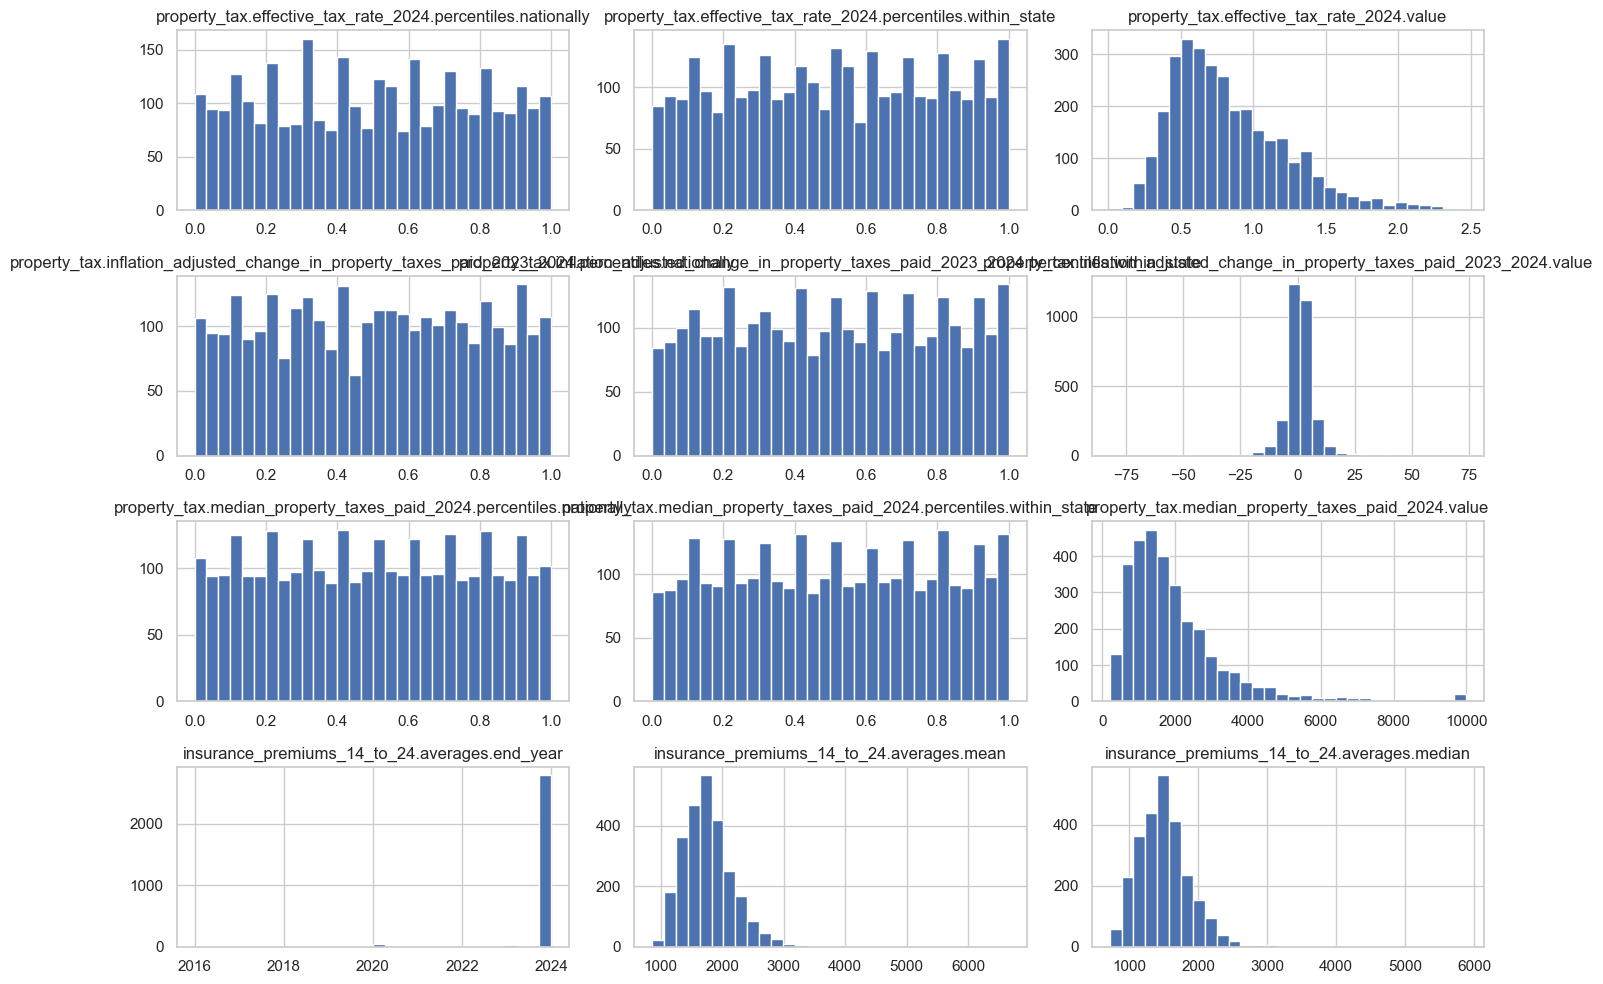

In [10]:
candidate_cols = [c for c in numeric.columns if any(token in c.lower() for token in ["risk", "claim", "premium", "tax", "population", "income", "value"])]
plot_cols = candidate_cols[:12]
if plot_cols:
    numeric[plot_cols].hist(figsize=(14, 10), bins=30)
    plt.tight_layout()
    plt.show()
else:
    print("No matching numeric columns found for quick histograms.")

## MSA And Redfin Coverage

In [11]:
if "has_redfin_data" in df.columns:
    display(df["has_redfin_data"].value_counts(dropna=False).to_frame("count"))
if "msa_type" in df.columns:
    display(df["msa_type"].value_counts(dropna=False).to_frame("count"))
if "msa_name" in df.columns:
    display(df["msa_name"].value_counts(dropna=True).head(25).to_frame("counties"))

,count
has_redfin_data,
True,3083
False,86


,count
msa_type,
None,1362
Metro,1166
Micro,641


,counties
msa_name,
"Atlanta-Sandy Springs-Roswell, GA",29
"New York-Newark-Jersey City, NY-NJ-PA",25
"Washington-Arlington-Alexandria, DC-VA-MD-WV",24
"Richmond, VA",17
"Minneapolis-St. Paul-Bloomington, MN-WI",16
"Virginia Beach-Norfolk-Newport News, VA-NC",16
"St. Louis, MO-IL",15
"Cincinnati, OH-KY-IN",15
"Nashville-Davidson--Murfreesboro--Franklin, TN",14


## Nested Exploration Helpers

In [12]:
def first_non_null(column: str):
    values = df[column].dropna()
    return values.iloc[0] if not values.empty else None

def dict_scalar_frame(column: str) -> pd.DataFrame:
    rows = []
    for _, row in df[["fips", "county_name", "state", column]].dropna(subset=[column]).iterrows():
        value = row[column]
        if not isinstance(value, dict):
            continue
        flat = {"fips": row["fips"], "county_name": row["county_name"], "state": row["state"]}
        for key, item in value.items():
            if isinstance(item, dict):
                if "value" in item:
                    flat[key] = item.get("value")
                for pct_key, pct_value in item.get("percentiles", {}).items():
                    flat[f"{key}.{pct_key}"] = pct_value
            elif np.isscalar(item) or item is None:
                flat[key] = item
        rows.append(flat)
    return pd.DataFrame(rows)

def records_from_array_column(column: str) -> pd.DataFrame:
    rows = []
    for _, row in df[["fips", "county_name", "state", column]].dropna(subset=[column]).iterrows():
        values = row[column]
        if isinstance(values, dict):
            values = [values]
        for item in values:
            if isinstance(item, dict):
                rows.append({"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], **item})
    return pd.DataFrame(rows)

def nested_numeric_summary(frame: pd.DataFrame, id_cols=("fips", "county_name", "state")) -> pd.DataFrame:
    numeric = frame.drop(columns=[c for c in id_cols if c in frame.columns], errors="ignore").select_dtypes(include="number")
    if numeric.empty:
        return pd.DataFrame()
    return numeric.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.sort_values("std", ascending=False)

def completeness_report(frame: pd.DataFrame, id_cols=("fips", "county_name", "state")) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()
    data = frame.drop(columns=[c for c in id_cols if c in frame.columns], errors="ignore")
    missing = data.isna().sum()
    return (
        pd.DataFrame({
            "non_null_count": data.notna().sum(),
            "missing_count": missing,
            "missing_pct": missing / len(data) * 100,
            "dtype": data.dtypes.astype(str),
        })
        .sort_values(["missing_pct", "missing_count"], ascending=False)
    )

## Nested Column: metrics

In [13]:
metrics_example = first_non_null("metrics")
print(f"Metric keys: {len(metrics_example)}")
display(pd.Series({k: type(v).__name__ for k, v in metrics_example.items()}).to_frame("type").head(60))

metric_lengths = []
for value in df["metrics"].dropna():
    if isinstance(value, dict):
        metric_lengths.append({k: len(v) for k, v in value.items() if hasattr(v, "__len__") and not isinstance(v, str)})
metric_lengths = pd.DataFrame(metric_lengths)
display(completeness_report(metric_lengths).head(60))
display(metric_lengths.describe().T.head(60))

Metric keys: 43


,type
AVG_SALE_TO_LIST,ndarray
AVG_SALE_TO_LIST_MOM,ndarray
AVG_SALE_TO_LIST_YOY,ndarray
HOMES_SOLD,ndarray
HOMES_SOLD_MOM,ndarray
HOMES_SOLD_YOY,ndarray
INVENTORY,ndarray
INVENTORY_MOM,ndarray
INVENTORY_YOY,ndarray
MEDIAN_DOM,ndarray


,non_null_count,missing_count,missing_pct,dtype
AVG_SALE_TO_LIST,3083,0,0.0,int64
AVG_SALE_TO_LIST_MOM,3083,0,0.0,int64
AVG_SALE_TO_LIST_YOY,3083,0,0.0,int64
HOMES_SOLD,3083,0,0.0,int64
HOMES_SOLD_MOM,3083,0,0.0,int64
HOMES_SOLD_YOY,3083,0,0.0,int64
INVENTORY,3083,0,0.0,int64
INVENTORY_MOM,3083,0,0.0,int64
INVENTORY_YOY,3083,0,0.0,int64
MEDIAN_DOM,3083,0,0.0,int64


,count,mean,std,min,25%,50%,75%,max
AVG_SALE_TO_LIST,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
AVG_SALE_TO_LIST_MOM,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
AVG_SALE_TO_LIST_YOY,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
HOMES_SOLD,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
HOMES_SOLD_MOM,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
HOMES_SOLD_YOY,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
INVENTORY,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
INVENTORY_MOM,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
INVENTORY_YOY,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0
MEDIAN_DOM,3083.0,66.992215,15.112018,1.0,72.0,73.0,73.0,73.0


In [14]:
metrics_rows = []
selected_metrics = [
    "MEDIAN_SALE_PRICE", "MEDIAN_LIST_PRICE", "HOMES_SOLD", "INVENTORY",
    "MONTHS_OF_SUPPLY", "MEDIAN_DOM", "SOLD_ABOVE_LIST", "PRICE_DROPS",
]
for _, row in df[["fips", "county_name", "state", "metrics"]].dropna(subset=["metrics"]).iterrows():
    value = row["metrics"]
    if not isinstance(value, dict) or "dates" not in value:
        continue
    dates = pd.to_datetime(value["dates"], errors="coerce")
    for metric in selected_metrics:
        if metric in value:
            metric_values = np.asarray(value[metric], dtype="float64")
            n = min(len(dates), len(metric_values))
            metrics_rows.extend(
                {
                    "fips": row["fips"],
                    "county_name": row["county_name"],
                    "state": row["state"],
                    "date": dates[i],
                    "metric": metric,
                    "value": metric_values[i],
                }
                for i in range(n)
            )

metrics_long = pd.DataFrame(metrics_rows)
display(metrics_long.head())
display(completeness_report(metrics_long))
display(metrics_long.groupby("metric")["value"].describe().sort_values("count", ascending=False))

,fips,county_name,state,date,metric,value
0,01001,Autauga County,AL,NaT,MEDIAN_SALE_PRICE,181190.0
1,01001,Autauga County,AL,NaT,MEDIAN_SALE_PRICE,203000.0
2,01001,Autauga County,AL,NaT,MEDIAN_SALE_PRICE,186583.0
3,01001,Autauga County,AL,NaT,MEDIAN_SALE_PRICE,180000.0
4,01001,Autauga County,AL,NaT,MEDIAN_SALE_PRICE,224000.0


,non_null_count,missing_count,missing_pct,dtype
date,0,1652296,100.000000,datetime64[ns]
value,1591670,60626,3.669197,float64
metric,1652296,0,0.000000,object


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
HOMES_SOLD,206391.0,96.988958,2.514297e+02,1.0,7.000,23.000,74.000,7318.0
MEDIAN_SALE_PRICE,206385.0,269246.320009,2.928437e+05,1.0,155000.000,220050.500,319000.000,38127000.0
MEDIAN_DOM,205958.0,71.101229,1.037815e+02,1.0,35.000,55.000,81.000,7428.0
MONTHS_OF_SUPPLY,205680.0,4.201224,6.287722e+00,0.0,2.200,3.200,4.800,792.0
SOLD_ABOVE_LIST,205515.0,0.206534,1.871942e-01,0.0,0.000,0.182,0.321,1.0
INVENTORY,204085.0,252.605689,6.466354e+02,1.0,28.000,75.000,211.000,18341.0
MEDIAN_LIST_PRICE,201164.0,278587.909775,2.239084e+06,100.0,165000.000,232450.000,329000.000,999999998.0
PRICE_DROPS,156492.0,0.223052,1.121174e-01,0.0,0.146,0.215,0.286,1.0


In [15]:
if not metrics_long.empty:
    latest_metrics = (
        metrics_long.dropna(subset=["date"])
        .sort_values("date")
        .groupby(["fips", "county_name", "state", "metric"], as_index=False)
        .tail(1)
    )
    latest_wide = (
        latest_metrics.pivot(index=["fips", "county_name", "state"], columns="metric", values="value")
        .reset_index()
        .rename_axis(columns=None)
    )
    display(latest_wide.head())
    display(latest_wide.describe().T)

    if "MEDIAN_SALE_PRICE" in latest_wide.columns:
        top_price_cols = [c for c in ["fips", "county_name", "state", "MEDIAN_SALE_PRICE", "HOMES_SOLD", "INVENTORY"] if c in latest_wide.columns]
        top_price = latest_wide.sort_values("MEDIAN_SALE_PRICE", ascending=False).head(20)
        display(top_price[top_price_cols])

,fips,county_name,state


,count,unique,top,freq
fips,0,0,NaN,NaN
county_name,0,0,NaN,NaN
state,0,0,NaN,NaN


## Nested Column: nfip_claims

In [16]:
nfip_example = first_non_null("nfip_claims")
display(pd.Series({k: type(v).__name__ for k, v in nfip_example.items()}).to_frame("type"))

nfip_rows = []
for _, row in df[["fips", "county_name", "state", "nfip_claims"]].dropna(subset=["nfip_claims"]).iterrows():
    value = row["nfip_claims"]
    if not isinstance(value, dict):
        continue
    year_values = np.asarray(value.get("yearOfLoss", []))
    n = len(year_values)
    for i in range(n):
        record = {"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "yearOfLoss": year_values[i]}
        for key, item in value.items():
            if key == "yearOfLoss" or not hasattr(item, "__len__"):
                continue
            if i < len(item):
                record[key] = item[i]
        nfip_rows.append(record)
nfip_long = pd.DataFrame(nfip_rows)
display(nfip_long.head())
display(nfip_long.shape)
display(completeness_report(nfip_long).head(40))

,type
amountPaidOnBuildingClaim,ndarray
amountPaidOnContentsClaim,ndarray
buildingDamageAmount,ndarray
buildingPropertyValue,ndarray
buildingReplacementCost,ndarray
contentsDamageAmount,ndarray
contentsPropertyValue,ndarray
contentsReplacementCost,ndarray
netBuildingPaymentAmount,ndarray
netContentsPaymentAmount,ndarray


,fips,county_name,state,yearOfLoss,amountPaidOnBuildingClaim,amountPaidOnContentsClaim,buildingDamageAmount,buildingPropertyValue,buildingReplacementCost,contentsDamageAmount,contentsPropertyValue,contentsReplacementCost,netBuildingPaymentAmount,netContentsPaymentAmount,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage
0,01001,Autauga County,AL,2005,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1,139800.0,0.0
1,01001,Autauga County,AL,2009,219564.44,33144.08,221387.0,972462.0,1331850.0,35648.0,0.0,0.0,219564.44,33144.08,12,1549300.0,468700.0
2,01001,Autauga County,AL,2011,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1,31400.0,0.0
3,01001,Autauga County,AL,2012,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1,50000.0,20000.0
4,01001,Autauga County,AL,2013,43792.16,0.00,44793.0,385527.0,566952.0,781.0,0.0,0.0,43792.16,0.00,1,500000.0,100000.0


(26623, 17)

,non_null_count,missing_count,missing_pct,dtype
yearOfLoss,26623,0,0.0,int64
amountPaidOnBuildingClaim,26623,0,0.0,float64
amountPaidOnContentsClaim,26623,0,0.0,float64
buildingDamageAmount,26623,0,0.0,float64
buildingPropertyValue,26623,0,0.0,float64
buildingReplacementCost,26623,0,0.0,float64
contentsDamageAmount,26623,0,0.0,float64
contentsPropertyValue,26623,0,0.0,float64
contentsReplacementCost,26623,0,0.0,float64
netBuildingPaymentAmount,26623,0,0.0,float64


,count,mean,std,min,25%,50%,75%,max
yearOfLoss,26623.0,2.014843e+03,5.854861e+00,2005.00,2010.00,2015.00,2020.000,2.026000e+03
total_paid,26623.0,5.536360e+06,1.423203e+08,-24452.52,6261.81,53357.38,322819.270,1.337998e+10
amountPaidOnBuildingClaim,26623.0,2.310711e+06,5.874665e+07,-12226.26,2834.21,23862.94,139607.655,5.532550e+09
amountPaidOnContentsClaim,26623.0,4.597779e+05,1.300611e+07,-8789.00,0.00,0.00,16183.780,1.186782e+09
netBuildingPaymentAmount,26623.0,2.308107e+06,5.868720e+07,-12226.26,2826.67,23773.71,139559.040,5.525379e+09
netContentsPaymentAmount,26623.0,4.577641e+05,1.292880e+07,-8789.00,0.00,0.00,16172.150,1.185045e+09


,fips,county_name,state,claim_records,total_paid,avg_paid
2308,48201,Harris County,TX,21,1.437470e+10,6.845096e+08
996,22071,Orleans Parish,LA,22,1.368965e+10,6.222570e+08
313,12071,Lee County,FL,21,7.732376e+09,3.682084e+08
330,12103,Pinellas County,FL,22,7.075655e+09,3.216207e+08
986,22051,Jefferson Parish,LA,22,5.901845e+09,2.682657e+08
1553,34029,Ocean County,NJ,22,4.708945e+09,2.140429e+08
2295,48167,Galveston County,TX,21,4.390012e+09,2.090482e+08
1004,22087,St. Bernard Parish,LA,21,4.389690e+09,2.090329e+08
1618,36059,Nassau County,NY,21,4.385862e+09,2.088506e+08
1012,22103,St. Tammany Parish,LA,22,3.212424e+09,1.460193e+08


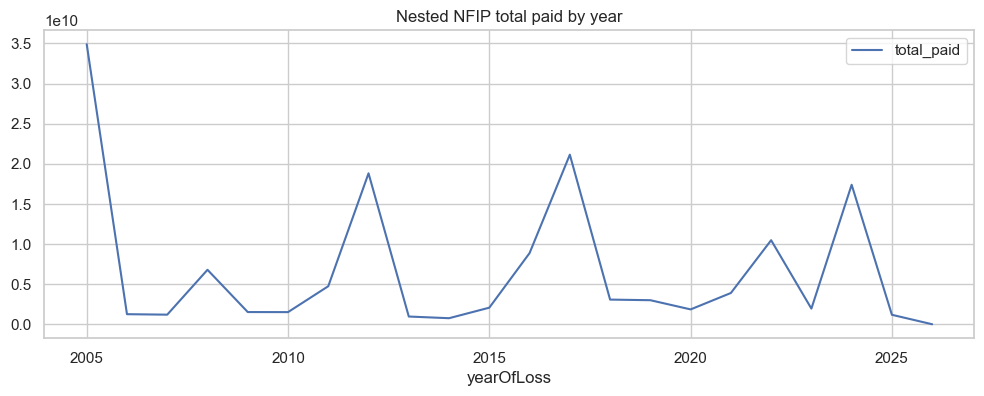

In [17]:
if not nfip_long.empty:
    claim_amount_cols = [
        "amountPaidOnBuildingClaim", "amountPaidOnContentsClaim",
        "amountPaidOnIncreasedCostOfComplianceClaim", "netBuildingPaymentAmount", "netContentsPaymentAmount",
    ]
    claim_amount_cols = [c for c in claim_amount_cols if c in nfip_long.columns]
    nfip_long["total_paid"] = nfip_long[claim_amount_cols].fillna(0).sum(axis=1)
    display(nfip_long[["yearOfLoss", "total_paid", *claim_amount_cols]].describe().T)
    display(
        nfip_long.groupby(["fips", "county_name", "state"], as_index=False)
        .agg(claim_records=("yearOfLoss", "size"), total_paid=("total_paid", "sum"), avg_paid=("total_paid", "mean"))
        .sort_values("total_paid", ascending=False)
        .head(25)
    )
    annual_nfip = nfip_long.groupby("yearOfLoss", as_index=False).agg(claim_records=("total_paid", "size"), total_paid=("total_paid", "sum"))
    annual_nfip.plot(x="yearOfLoss", y="total_paid", figsize=(12, 4), title="Nested NFIP total paid by year")
    plt.show()

## Nested Column: property_tax

,fips,county_name,state,effective_tax_rate_2024,effective_tax_rate_2024.nationally,effective_tax_rate_2024.within_state,inflation_adjusted_change_in_property_taxes_paid_2023_2024,inflation_adjusted_change_in_property_taxes_paid_2023_2024.nationally,inflation_adjusted_change_in_property_taxes_paid_2023_2024.within_state,median_property_taxes_paid_2024,median_property_taxes_paid_2024.nationally,median_property_taxes_paid_2024.within_state
0,01001,Autauga County,AL,0.28,0.03,0.53,7.8,0.92,0.85,627.0,0.07,0.72
1,01003,Baldwin County,AL,0.29,0.03,0.60,5.7,0.86,0.71,960.0,0.21,0.94
2,01005,Barbour County,AL,0.31,0.04,0.72,8.0,0.92,0.86,462.0,0.03,0.48
3,01007,Bibb County,AL,0.20,0.01,0.07,6.7,0.90,0.79,298.0,0.01,0.06
4,01009,Blount County,AL,0.27,0.02,0.46,-0.1,0.40,0.23,523.0,0.04,0.60


,non_null_count,missing_count,missing_pct,dtype
inflation_adjusted_change_in_property_taxes_paid_2023_2024,3101,33,1.052967,float64
inflation_adjusted_change_in_property_taxes_paid_2023_2024.nationally,3101,33,1.052967,float64
inflation_adjusted_change_in_property_taxes_paid_2023_2024.within_state,3101,33,1.052967,float64
effective_tax_rate_2024,3126,8,0.255265,float64
effective_tax_rate_2024.nationally,3126,8,0.255265,float64
effective_tax_rate_2024.within_state,3126,8,0.255265,float64
median_property_taxes_paid_2024,3128,6,0.191449,float64
median_property_taxes_paid_2024.nationally,3128,6,0.191449,float64
median_property_taxes_paid_2024.within_state,3128,6,0.191449,float64


,count,mean,std,min,5%,25%,50%,75%,95%,max
median_property_taxes_paid_2024,3128.0,1980.321931,1438.402991,199.00,552.35,1053.75,1619.50,2453.50,4609.45,10001.00
inflation_adjusted_change_in_property_taxes_paid_2023_2024,3101.0,1.005708,6.224414,-82.10,-7.50,-1.70,0.80,3.50,10.00,73.70
effective_tax_rate_2024,3126.0,0.831113,0.397900,0.01,0.33,0.53,0.74,1.06,1.58,2.47
inflation_adjusted_change_in_property_taxes_paid_2023_2024.nationally,3101.0,0.500803,0.288996,0.00,0.05,0.25,0.50,0.75,0.95,1.00
median_property_taxes_paid_2024.within_state,3128.0,0.507983,0.288954,0.00,0.06,0.26,0.51,0.76,0.96,1.00
inflation_adjusted_change_in_property_taxes_paid_2023_2024.within_state,3101.0,0.508020,0.288929,0.00,0.06,0.26,0.51,0.76,0.96,1.00
effective_tax_rate_2024.within_state,3126.0,0.507927,0.288708,0.00,0.06,0.26,0.51,0.76,0.96,1.00
effective_tax_rate_2024.nationally,3126.0,0.499012,0.288312,0.00,0.05,0.24,0.50,0.75,0.95,1.00
median_property_taxes_paid_2024.nationally,3128.0,0.498830,0.288000,0.00,0.05,0.25,0.50,0.75,0.95,1.00


,fips,county_name,state,effective_tax_rate_2024,inflation_adjusted_change_in_property_taxes_paid_2023_2024,median_property_taxes_paid_2024
1769,34007,Camden County,NJ,2.47,-2.1,8134.0
1847,36055,Monroe County,NY,2.41,-0.9,5616.0
1773,34015,Gloucester County,NJ,2.40,-1.9,8055.0
1821,36003,Allegany County,NY,2.37,-0.1,2968.0
633,17093,Kendall County,IL,2.28,-1.8,7651.0
687,17201,Winnebago County,IL,2.28,-1.0,3930.0
642,17111,McHenry County,IL,2.26,-1.4,7274.0
635,17097,Lake County,IL,2.26,-1.0,8923.0
1781,34031,Passaic County,NJ,2.26,NaN,10001.0
1786,34041,Warren County,NJ,2.26,-3.4,8119.0


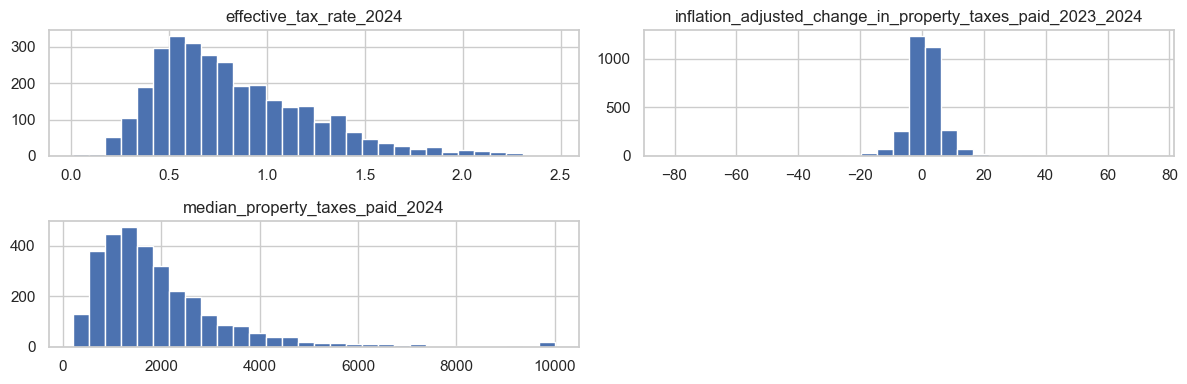

In [18]:
property_tax_flat = dict_scalar_frame("property_tax")
display(property_tax_flat.head())
display(completeness_report(property_tax_flat))
display(nested_numeric_summary(property_tax_flat))

value_cols = [c for c in property_tax_flat.columns if c.endswith("_2024") or c.endswith("_2023_2024")]
if value_cols:
    display(property_tax_flat[["fips", "county_name", "state", *value_cols]].sort_values(value_cols[0], ascending=False).head(25))
    property_tax_flat[value_cols].hist(figsize=(12, 4), bins=30)
    plt.tight_layout()
    plt.show()

## Nested Column: insurance_premiums_14_to_24

In [19]:
premium_rows = []
premium_history_rows = []
for _, row in df[["fips", "county_name", "state", "insurance_premiums_14_to_24"]].dropna(subset=["insurance_premiums_14_to_24"]).iterrows():
    value = row["insurance_premiums_14_to_24"]
    if not isinstance(value, dict):
        continue
    flat = {"fips": row["fips"], "county_name": row["county_name"], "state": row["state"]}
    for section in ["averages", "growth_rates", "latest"]:
        for key, item in value.get(section, {}).items():
            if isinstance(item, dict):
                for pct_key, pct_value in item.items():
                    flat[f"{section}.{key}.{pct_key}"] = pct_value
            elif np.isscalar(item) or item is None:
                flat[f"{section}.{key}"] = item
    premium_rows.append(flat)

    historical = value.get("historical", {})
    years = np.arange(value.get("averages", {}).get("start_year", 2014), value.get("averages", {}).get("end_year", 2024) + 1)
    for metric in ["mean", "median"]:
        values = historical.get(metric)
        if values is None:
            continue
        for year, premium in zip(years, values):
            premium_history_rows.append({"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "year": year, "metric": metric, "premium": premium})

premium_flat = pd.DataFrame(premium_rows)
premium_history = pd.DataFrame(premium_history_rows)
display(premium_flat.head())
display(completeness_report(premium_flat).head(40))
display(completeness_report(premium_history).head(20))
display(nested_numeric_summary(premium_flat).head(30))

,fips,county_name,state,averages.end_year,averages.mean,averages.median,averages.start_year,growth_rates.end_year,growth_rates.mean_cagr,growth_rates.median_cagr,growth_rates.percentiles.mean_cagr_nationally,growth_rates.percentiles.mean_cagr_within_state,growth_rates.percentiles.median_cagr_nationally,growth_rates.percentiles.median_cagr_within_state,growth_rates.start_year,latest.mean,latest.median,latest.percentiles.mean_nationally,latest.percentiles.mean_within_state,latest.percentiles.median_nationally,latest.percentiles.median_within_state,latest.year
0,01001,Autauga County,AL,2024,1652.18,1472.64,2014,2024,0.048405,0.054496,0.418,0.692,0.478,0.815,2014,2299.0,2040.0,0.393,0.108,0.456,0.108,2024
1,01003,Baldwin County,AL,2024,2622.18,2232.73,2014,2024,0.030283,0.025484,0.104,0.077,0.062,0.031,2014,3648.0,3007.0,0.941,1.000,0.920,1.000,2024
2,01005,Barbour County,AL,2024,1815.27,1553.55,2014,2024,0.040061,0.044193,0.231,0.338,0.255,0.446,2014,2392.0,2085.0,0.460,0.185,0.492,0.185,2024
3,01007,Bibb County,AL,2024,1792.73,1608.91,2014,2024,0.041973,0.045275,0.269,0.431,0.273,0.477,2014,2465.0,2183.0,0.517,0.362,0.570,0.385,2024
4,01009,Blount County,AL,2024,1811.00,1624.64,2014,2024,0.046390,0.050037,0.367,0.600,0.378,0.677,2014,2518.0,2234.0,0.557,0.492,0.608,0.508,2024


,non_null_count,missing_count,missing_pct,dtype
averages.mean,2632,241,8.388444,float64
averages.median,2632,241,8.388444,float64
growth_rates.mean_cagr,2632,241,8.388444,float64
growth_rates.median_cagr,2632,241,8.388444,float64
growth_rates.percentiles.mean_cagr_nationally,2632,241,8.388444,float64
growth_rates.percentiles.mean_cagr_within_state,2632,241,8.388444,float64
growth_rates.percentiles.median_cagr_nationally,2632,241,8.388444,float64
growth_rates.percentiles.median_cagr_within_state,2632,241,8.388444,float64
latest.mean,2632,241,8.388444,float64
latest.median,2632,241,8.388444,float64


,non_null_count,missing_count,missing_pct,dtype
premium,57878,3070,5.037081,float64
year,60948,0,0.000000,int64
metric,60948,0,0.000000,object


,count,mean,std,min,5%,25%,50%,75%,95%,max
latest.mean,2632.0,2528.470365,700.036942,1172.000000,1623.550000,2063.750000,2442.500000,2853.000000,3751.800000,9400.000000
latest.median,2632.0,2165.976444,629.178778,879.000000,1326.550000,1745.750000,2093.500000,2459.250000,3297.350000,8402.000000
averages.mean,2632.0,1777.866448,447.037578,860.180000,1192.739000,1482.910000,1728.315000,1991.475000,2525.013500,6663.000000
averages.median,2632.0,1507.505490,399.707961,715.360000,960.109000,1236.797500,1476.775000,1706.680000,2164.423000,5887.360000
averages.start_year,2873.0,2014.271841,1.129913,2014.000000,2014.000000,2014.000000,2014.000000,2014.000000,2016.000000,2024.000000
growth_rates.start_year,2873.0,2014.271841,1.129913,2014.000000,2014.000000,2014.000000,2014.000000,2014.000000,2016.000000,2024.000000
averages.end_year,2873.0,2023.908110,0.601108,2016.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
latest.year,2873.0,2023.908110,0.601108,2016.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
growth_rates.end_year,2873.0,2023.908110,0.601108,2016.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
growth_rates.percentiles.mean_cagr_within_state,2632.0,0.509688,0.288942,0.005000,0.059550,0.260000,0.510000,0.760000,0.958450,1.000000


count         mean         std     min      25%     50%  \
year metric                                                             
2019 mean    2632.0  1656.042933  423.521339   757.0  1360.00  1602.0   
     median  2632.0  1407.828267  378.549445   637.0  1142.00  1378.0   
2020 mean    2632.0  1699.941489  437.216675   794.0  1410.00  1649.0   
     median  2632.0  1435.338146  380.272114   649.0  1176.00  1413.0   
2021 mean    2632.0  1754.027736  439.815931   854.0  1453.00  1715.0   
     median  2632.0  1502.979863  396.906389   699.0  1227.75  1479.5   
2022 mean    2632.0  1949.996201  507.508131   872.0  1600.00  1888.0   
     median  2632.0  1672.153495  458.155858   712.0  1357.00  1634.5   
2023 mean    2632.0  2225.346884  612.538230  1043.0  1829.00  2134.0   
     median  2632.0  1894.563830  539.226679   842.0  1532.00  1833.5   
2024 mean    2619.0  2531.228331  700.596190  1172.0  2069.00  2446.0   
     median  2619.0  2168.626957  629.543500   879.0  1754.00  2095.0   

                 75%     max  
year metric                   
2019 mean    1878.00  6023.0  
     median  1609.00  5288.0  
2020 mean    1930.00  7151.0  
     median  1639.25  5366.0  
2021 mean    1982.00  6408.0  
     median  1722.00  5537.0  
2022 mean    2202.00  7250.0  
     median  1910.00  6330.0  
2023 mean    2495.25  8331.0  
     median  2151.00  7472.0  
2024 mean    2854.50  9400.0  
     median  2460.00  8402.0

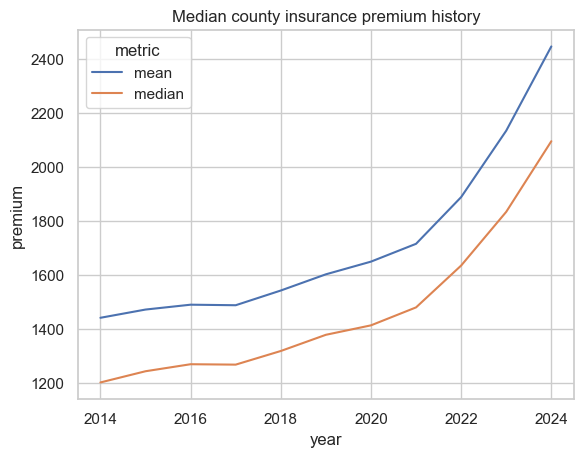

,fips,county_name,state,latest.mean
335,12087,Monroe County,FL,9400.0
1044,22071,Orleans Parish,LA,7513.0
297,12011,Broward County,FL,6865.0
266,08097,Pitkin County,CO,6835.0
309,12037,Franklin County,FL,6757.0
1046,22075,Plaquemines Parish,LA,6546.0
334,12086,Miami-Dade County,FL,6375.0
341,12099,Palm Beach County,FL,6326.0
333,12085,Martin County,FL,6182.0
1728,36119,Westchester County,NY,5903.0


In [20]:
if not premium_history.empty:
    display(premium_history.groupby(["year", "metric"])["premium"].describe().tail(12))
    premium_trend = premium_history.groupby(["year", "metric"], as_index=False)["premium"].median()
    sns.lineplot(data=premium_trend, x="year", y="premium", hue="metric")
    plt.title("Median county insurance premium history")
    plt.show()

latest_mean_col = "latest.mean"
if latest_mean_col in premium_flat.columns:
    display(premium_flat.sort_values(latest_mean_col, ascending=False).head(25)[["fips", "county_name", "state", latest_mean_col]])

## Nested Column: insurance_non_renewal_rates

In [21]:
nonrenewal_rows = []
nonrenewal_history_rows = []
for _, row in df[["fips", "county_name", "state", "insurance_non_renewal_rates"]].dropna(subset=["insurance_non_renewal_rates"]).iterrows():
    value = row["insurance_non_renewal_rates"]
    if not isinstance(value, dict):
        continue
    flat = {"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "years_of_data": value.get("years_of_data")}
    for section in ["averages", "growth_rates", "latest"]:
        for key, item in value.get(section, {}).items():
            if isinstance(item, dict):
                for pct_key, pct_value in item.items():
                    flat[f"{section}.{key}.{pct_key}"] = pct_value
            elif np.isscalar(item) or item is None:
                flat[f"{section}.{key}"] = item
    nonrenewal_rows.append(flat)

    historical = value.get("historical", {})
    end_year = value.get("averages", {}).get("end_year", 2023)
    n_years = len(next(iter(historical.values()))) if historical else 0
    years = np.arange(end_year - n_years + 1, end_year + 1)
    for metric, values in historical.items():
        for year, metric_value in zip(years, values):
            nonrenewal_history_rows.append({"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "year": year, "metric": metric, "value": metric_value})

nonrenewal_flat = pd.DataFrame(nonrenewal_rows)
nonrenewal_history = pd.DataFrame(nonrenewal_history_rows)
display(nonrenewal_flat.head())
display(completeness_report(nonrenewal_flat).head(40))
display(completeness_report(nonrenewal_history).head(20))
display(nested_numeric_summary(nonrenewal_flat).head(30))

,fips,county_name,state,years_of_data,averages.end_year,averages.non_renewal_rate,averages.num_policies_non_renewed,averages.num_policies_renewed,averages.num_policies_total,averages.start_year,growth_rates.end_year,growth_rates.non_renewal_rate_cagr,growth_rates.num_policies_non_renewed_cagr,growth_rates.num_policies_renewed_cagr,growth_rates.num_policies_total_cagr,growth_rates.percentiles.non_renewal_rate_cagr_nationally,growth_rates.percentiles.non_renewal_rate_cagr_within_state,growth_rates.percentiles.num_policies_non_renewed_cagr_nationally,growth_rates.percentiles.num_policies_non_renewed_cagr_within_state,growth_rates.percentiles.num_policies_renewed_cagr_nationally,growth_rates.percentiles.num_policies_renewed_cagr_within_state,growth_rates.percentiles.num_policies_total_cagr_nationally,growth_rates.percentiles.num_policies_total_cagr_within_state,growth_rates.start_year,latest.non_renewal_rate,latest.num_policies_non_renewed,latest.num_policies_renewed,latest.num_policies_total,latest.percentiles.non_renewal_rate_nationally,latest.percentiles.non_renewal_rate_within_state,latest.percentiles.num_policies_non_renewed_nationally,latest.percentiles.num_policies_non_renewed_within_state,latest.percentiles.num_policies_renewed_nationally,latest.percentiles.num_policies_renewed_within_state,latest.percentiles.num_policies_total_nationally,latest.percentiles.num_policies_total_within_state,latest.year
0,01001,Autauga County,AL,6,2023,0.01,47.17,7806.50,7853.67,2018,2023,0.0,-0.114167,0.028103,0.026623,0.44,0.5,0.049,0.060,0.695,0.761,0.672,0.716,2018,0.01,54.0,8207.00,8261.00,0.467,0.478,0.654,0.627,0.723,0.701,0.722,0.701,2023
1,01003,Baldwin County,AL,6,2023,0.01,247.33,26540.17,26787.50,2018,2023,0.0,0.349189,0.070755,0.072119,0.44,0.5,0.934,1.000,0.959,1.000,0.960,1.000,2018,0.01,304.0,32510.59,32814.59,0.467,0.478,0.903,0.940,0.905,0.925,0.905,0.925,2023
2,01005,Barbour County,AL,6,2023,0.01,14.83,1939.50,1954.33,2018,2023,0.0,0.000000,0.043266,0.042784,0.44,0.5,0.282,0.485,0.848,0.970,0.840,0.970,2018,0.01,21.0,2122.00,2143.00,0.467,0.478,0.402,0.291,0.402,0.284,0.402,0.284,2023
3,01007,Bibb County,AL,6,2023,0.01,17.67,2474.67,2492.33,2018,2023,0.0,-0.090977,0.005821,0.004870,0.44,0.5,0.072,0.134,0.304,0.104,0.276,0.075,2018,0.01,18.0,2482.00,2500.00,0.467,0.478,0.364,0.201,0.439,0.313,0.437,0.313,2023
4,01009,Blount County,AL,6,2023,0.01,48.67,7639.83,7688.50,2018,2023,0.0,-0.021828,0.015443,0.015127,0.44,0.5,0.204,0.343,0.493,0.373,0.476,0.358,2018,0.01,60.0,7863.00,7923.00,0.467,0.478,0.678,0.657,0.715,0.672,0.714,0.672,2023


,non_null_count,missing_count,missing_pct,dtype
growth_rates.non_renewal_rate_cagr,2815,298,9.572759,float64
growth_rates.percentiles.non_renewal_rate_cagr_nationally,2815,298,9.572759,float64
growth_rates.percentiles.non_renewal_rate_cagr_within_state,2815,298,9.572759,float64
growth_rates.num_policies_non_renewed_cagr,3071,42,1.349181,float64
growth_rates.percentiles.num_policies_non_renewed_cagr_nationally,3071,42,1.349181,float64
growth_rates.percentiles.num_policies_non_renewed_cagr_within_state,3071,42,1.349181,float64
growth_rates.num_policies_renewed_cagr,3089,24,0.770960,float64
growth_rates.num_policies_total_cagr,3089,24,0.770960,float64
growth_rates.percentiles.num_policies_renewed_cagr_nationally,3089,24,0.770960,float64
growth_rates.percentiles.num_policies_renewed_cagr_within_state,3089,24,0.770960,float64


,non_null_count,missing_count,missing_pct,dtype
year,92665,0,0.0,int64
metric,92665,0,0.0,object
value,92665,0,0.0,float64


,count,mean,std,min,5%,25%,50%,75%,95%,max
averages.num_policies_total,3113.0,13264.244192,41056.188009,2.000000,181.166000,1065.670000,3087.670000,9473.170000,59958.802000,1203746.54
latest.num_policies_total,3113.0,13475.966322,40984.399633,2.000000,185.000000,1109.000000,3228.000000,9701.000000,59229.166000,1179681.66
averages.num_policies_renewed,3113.0,13159.072499,40682.539981,1.000000,179.300000,1056.330000,3061.830000,9386.620000,59427.930000,1189840.20
latest.num_policies_renewed,3113.0,13334.220418,40527.438131,1.000000,183.600000,1101.000000,3175.000000,9603.000000,58748.566000,1162756.66
latest.num_policies_non_renewed,3113.0,141.746226,521.827833,0.000000,2.000000,11.000000,30.000000,91.000000,616.400000,16925.00
averages.num_policies_non_renewed,3113.0,101.451307,376.520520,0.000000,1.670000,8.670000,22.500000,65.670000,422.634000,12934.67
years_of_data,3113.0,5.953742,0.463771,1.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.00
growth_rates.start_year,3113.0,2018.042724,0.441034,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2023.00
averages.start_year,3113.0,2018.042724,0.441034,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2023.00
growth_rates.percentiles.num_policies_renewed_cagr_within_state,3089.0,0.508255,0.288921,0.004000,0.058400,0.258000,0.507000,0.759000,0.958000,1.00


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2013,1.0,0.000000,NaN,0.0,0.000,0.00,0.000,0.00
2014,1.0,0.000000,NaN,0.0,0.000,0.00,0.000,0.00
2015,3.0,0.010000,0.010000,0.0,0.005,0.01,0.015,0.02
2016,3.0,0.010000,0.010000,0.0,0.005,0.01,0.015,0.02
2017,8.0,0.006250,0.005175,0.0,0.000,0.01,0.010,0.01
2018,3075.0,0.008514,0.008889,0.0,0.000,0.01,0.010,0.33
2019,3079.0,0.007847,0.007428,0.0,0.000,0.01,0.010,0.16
2020,3082.0,0.004783,0.007360,0.0,0.000,0.00,0.010,0.17
2021,3084.0,0.008132,0.006604,0.0,0.000,0.01,0.010,0.13


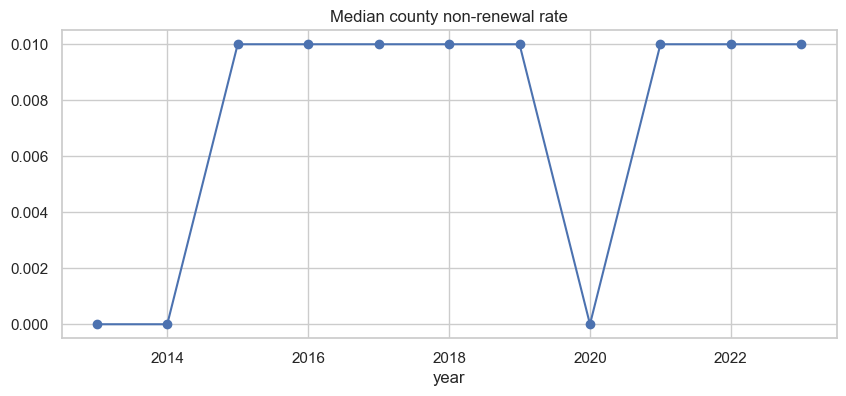

,fips,county_name,state,latest.non_renewal_rate,latest.num_policies_total
2911,51730,Petersburg City,VA,0.50,2.00
2899,51620,Franklin City,VA,0.29,7.00
2744,48495,Winkler County,TX,0.22,8.99
2896,51595,Emporia City,VA,0.20,5.00
2904,51678,Lexington City,VA,0.17,6.00
2903,51660,Harrisonburg City,VA,0.17,18.00
2892,51540,Charlottesville City,VA,0.17,18.00
329,12043,Glades County,FL,0.16,2915.00
2907,51685,Manassas Park City,VA,0.16,18.96
1900,37055,Dare County,NC,0.13,2847.87


In [22]:
if not nonrenewal_history.empty:
    rate_history = nonrenewal_history[nonrenewal_history["metric"].eq("non_renewal_rate")]
    display(rate_history.groupby("year")["value"].describe())
    rate_history.groupby("year")["value"].median().plot(figsize=(10, 4), marker="o", title="Median county non-renewal rate")
    plt.show()

latest_rate_col = "latest.non_renewal_rate"
if latest_rate_col in nonrenewal_flat.columns:
    display(nonrenewal_flat.sort_values(latest_rate_col, ascending=False).head(25)[["fips", "county_name", "state", latest_rate_col, "latest.num_policies_total"]])

## Nested Column: nri_climate

In [23]:
nri_flat = dict_scalar_frame("nri_climate")
display(nri_flat.head())
display(completeness_report(nri_flat).head(40))
display(nested_numeric_summary(nri_flat).head(30))

nri_risk_rows = []
for _, row in df[["fips", "county_name", "state", "nri_climate"]].dropna(subset=["nri_climate"]).iterrows():
    value = row["nri_climate"]
    if not isinstance(value, dict):
        continue
    for item in value.get("RISKS_BREAKDOWN", []):
        if isinstance(item, dict):
            flat = {"fips": row["fips"], "county_name": row["county_name"], "state": row["state"]}
            for key, val in item.items():
                if isinstance(val, dict):
                    for sub_key, sub_val in val.items():
                        flat[f"{key}.{sub_key}"] = sub_val
                else:
                    flat[key] = val
            nri_risk_rows.append(flat)
nri_risks = pd.DataFrame(nri_risk_rows)
display(nri_risks.head())
display(nri_risks.shape)
display(completeness_report(nri_risks).head(40))

,fips,county_name,state,AGRIVALUE,AREA,BUILDVALUE,COUNTY_FIPS,COUNTY_ID,NRI_ID,POPULATION,RISK_RATNG,RISK_SCORE,RISK_VALUE,STATE_ID
0,01001,Autauga County,AL,27630646.0,610.4705,1.024141e+10,001,01001,C01001,58764,None,57.5700,2.051090e+07,01
1,01003,Baldwin County,AL,155012958.0,2047.7388,5.160230e+10,003,01003,C01003,231365,None,96.7239,2.532687e+08,01
2,01005,Barbour County,AL,135914589.0,913.6465,5.441822e+09,005,01005,C01005,25160,None,48.1234,1.599858e+07,01
3,01007,Bibb County,AL,5410008.0,632.4868,3.532631e+09,007,01007,C01007,22239,None,39.1221,1.267247e+07,01
4,01009,Blount County,AL,312712010.0,657.1966,8.773489e+09,009,01009,C01009,58992,None,68.4796,2.870536e+07,01


,non_null_count,missing_count,missing_pct,dtype
RISK_RATNG,0,3134,100.0,object
AGRIVALUE,3134,0,0.0,float64
AREA,3134,0,0.0,float64
BUILDVALUE,3134,0,0.0,float64
COUNTY_FIPS,3134,0,0.0,object
COUNTY_ID,3134,0,0.0,object
NRI_ID,3134,0,0.0,object
POPULATION,3134,0,0.0,int64
RISK_SCORE,3134,0,0.0,float64
RISK_VALUE,3134,0,0.0,float64


,count,mean,std,min,5%,25%,50%,75%,95%,max
BUILDVALUE,3134.0,2.186222e+10,6.235153e+10,5.694155e+07,1.025890e+09,2.809855e+09,6.347549e+09,1.572601e+10,9.204044e+10,1.703725e+12
AGRIVALUE,3134.0,1.593808e+08,3.204836e+08,0.000000e+00,1.938379e+06,2.694242e+07,8.016296e+07,1.879837e+08,4.922763e+08,7.394104e+09
RISK_VALUE,3134.0,5.129214e+07,2.194611e+08,5.492046e+04,3.220437e+06,8.810281e+06,1.687128e+07,3.537094e+07,1.794711e+08,9.180158e+09
POPULATION,3134.0,1.044988e+05,3.350120e+05,6.400000e+01,2.616000e+03,1.077575e+04,2.557350e+04,6.754725e+04,4.431828e+05,1.000571e+07
AREA,3134.0,1.223854e+03,3.843235e+03,2.067100e+00,2.257981e+02,4.503880e+02,6.582510e+02,1.001866e+03,3.467593e+03,1.493636e+05
RISK_SCORE,3134.0,4.992384e+01,2.882851e+01,3.180000e-02,5.046135e+00,2.497615e+01,4.988870e+01,7.483305e+01,9.492203e+01,1.000000e+02


,fips,county_name,state,code,percentile.county,percentile.nation,percentile.state,risk,risk_rating_text,risk_score
0,01001,Autauga County,AL,AVLN,1.0,0.0003,0.0149,avalanche,Not Applicable,0.0000
1,01001,Autauga County,AL,CFLD,1.0,0.0003,0.0149,coastal_flooding,Not Applicable,0.0000
2,01001,Autauga County,AL,CWAV,1.0,0.3014,0.2090,cold_wave,Relatively Low,28.1807
3,01001,Autauga County,AL,DRGT,1.0,0.4712,0.3582,drought,Relatively Low,45.6425
4,01001,Autauga County,AL,ERQK,1.0,0.6872,0.4627,earthquake,Relatively Low,67.8435


(56412, 10)

,non_null_count,missing_count,missing_pct,dtype
code,56412,0,0.0,object
percentile.county,56412,0,0.0,float64
percentile.nation,56412,0,0.0,float64
percentile.state,56412,0,0.0,float64
risk,56412,0,0.0,object
risk_rating_text,56412,0,0.0,object
risk_score,56412,0,0.0,float64


,count,mean,std,min,25%,50%,75%,max
risk,,,,,,,,
hail,3134.0,50.061959,28.879896,0.0000,25.071550,50.11130,75.055650,100.0
wildfire,3134.0,50.053830,28.902927,0.0000,25.039750,50.14310,75.087450,100.0
tornado,3134.0,50.009256,28.883002,0.0318,24.976150,50.01590,75.023850,100.0
cold_wave,3134.0,49.991495,28.921320,0.0000,24.976150,49.98410,75.055650,100.0
lightning,3134.0,49.973593,28.867994,0.0318,24.976150,49.95230,74.928450,100.0
strong_wind,3134.0,49.973532,28.856680,0.0000,25.007950,49.95230,74.928450,100.0
landslide,3134.0,49.960460,28.865774,0.0318,24.976150,49.92050,74.928450,100.0
earthquake,3134.0,49.932875,28.860399,0.0000,24.944350,49.88870,74.896650,100.0
winter_weather,3134.0,49.919387,28.883948,0.0000,24.928375,49.88860,74.880650,100.0


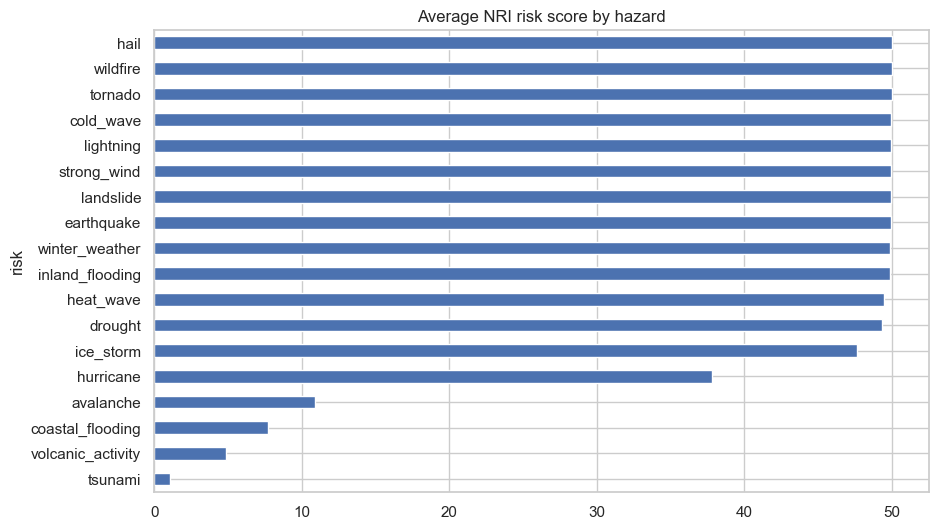

,fips,county_name,state,RISK_SCORE,RISK_RATNG,RISK_VALUE
205,06037,Los Angeles County,CA,100.0000,None,9.180158e+09
602,17031,Cook County,IL,99.9682,None,2.957063e+09
2615,48201,Harris County,TX,99.9364,None,2.947094e+09
219,06065,Riverside County,CA,99.9046,None,2.304891e+09
104,04013,Maricopa County,AZ,99.8728,None,2.118483e+09
222,06071,San Bernardino County,CA,99.8410,None,2.104012e+09
216,06059,Orange County,CA,99.8092,None,1.822512e+09
187,06001,Alameda County,CA,99.7774,None,1.776525e+09
229,06085,Santa Clara County,CA,99.7455,None,1.686687e+09
223,06073,San Diego County,CA,99.7137,None,1.462271e+09


In [24]:
if not nri_risks.empty:
    score_col = "risk_score" if "risk_score" in nri_risks.columns else None
    if score_col:
        display(nri_risks.groupby("risk")[score_col].describe().sort_values("mean", ascending=False).head(25))
        top_risks = nri_risks.groupby("risk")[score_col].mean().sort_values(ascending=False).head(20)
        top_risks.sort_values().plot(kind="barh", figsize=(10, 6), title="Average NRI risk score by hazard")
        plt.show()
    display(nri_flat.sort_values("RISK_SCORE", ascending=False).head(25)[["fips", "county_name", "state", "RISK_SCORE", "RISK_RATNG", "RISK_VALUE"]])

## Nested Column: temp_max_min

In [25]:
temp_records = records_from_array_column("temp_max_min")
display(temp_records.head())
display(temp_records.shape)
display(completeness_report(temp_records).head(60))
display(nested_numeric_summary(temp_records).head(40))

,fips,county_name,state,month,tmax_average_temp_c,tmax_average_temp_f,tmax_max_temp_c,tmax_max_temp_f,tmax_median_temp_c,tmax_median_temp_f,tmax_min_temp_c,tmax_min_temp_f,tmax_trend_slope_temp_c,tmax_trend_slope_temp_f,tmin_average_temp_c,tmin_average_temp_f,tmin_max_temp_c,tmin_max_temp_f,tmin_median_temp_c,tmin_median_temp_f,tmin_min_temp_c,tmin_min_temp_f,tmin_trend_slope_temp_c,tmin_trend_slope_temp_f,year
0,01001,Autauga County,AL,1,16.38,61.48,23.29,73.92,16.26,61.27,7.38,45.28,-0.20,-0.36,4.18,39.53,15.60,60.08,2.29,36.12,-4.66,23.61,-0.12,-0.22,2020
1,01001,Autauga County,AL,2,17.66,63.78,25.95,78.71,17.45,63.41,11.55,52.79,-0.17,-0.31,5.18,41.32,16.43,61.57,4.21,39.58,-1.34,29.59,-0.16,-0.28,2020
2,01001,Autauga County,AL,3,24.57,76.23,30.65,87.17,25.75,78.35,14.80,58.64,0.36,0.64,12.16,53.88,19.42,66.96,13.30,55.94,1.47,34.65,0.34,0.61,2020
3,01001,Autauga County,AL,4,24.18,75.53,28.65,83.57,24.10,75.38,17.53,63.55,-0.03,-0.05,9.96,49.93,17.34,63.21,10.45,50.81,4.21,39.58,0.02,0.03,2020
4,01001,Autauga County,AL,5,28.12,82.62,32.68,90.82,29.05,84.29,20.80,69.44,0.17,0.31,13.97,57.15,20.56,69.01,15.74,60.33,6.12,43.02,0.38,0.68,2020


(118178, 25)

,non_null_count,missing_count,missing_pct,dtype
month,118178,0,0.0,int64
tmax_average_temp_c,118178,0,0.0,float64
tmax_average_temp_f,118178,0,0.0,float64
tmax_max_temp_c,118178,0,0.0,float64
tmax_max_temp_f,118178,0,0.0,float64
tmax_median_temp_c,118178,0,0.0,float64
tmax_median_temp_f,118178,0,0.0,float64
tmax_min_temp_c,118178,0,0.0,float64
tmax_min_temp_f,118178,0,0.0,float64
tmax_trend_slope_temp_c,118178,0,0.0,float64


,count,mean,std,min,5%,25%,50%,75%,95%,max
tmax_min_temp_f,118178.0,48.032666,22.663185,-26.57,8.64,31.3200,48.970,67.0100,81.43,105.89
tmin_min_temp_f,118178.0,29.187348,21.236954,-44.55,-9.15,15.3900,29.790,45.2775,62.40,79.00
tmax_median_temp_f,118178.0,65.054656,18.948195,4.93,31.35,50.4900,68.090,81.0700,90.79,112.69
tmax_average_temp_f,118178.0,64.697837,18.714913,9.78,30.84,50.6000,67.390,80.5200,90.31,112.14
tmin_median_temp_f,118178.0,42.861423,17.556758,-17.34,14.00,29.6150,43.030,57.4200,70.25,84.96
tmin_average_temp_f,118178.0,42.721242,17.459878,-14.80,12.99,29.7625,43.440,56.9400,69.70,84.18
tmax_max_temp_f,118178.0,78.881756,15.387865,25.86,48.27,69.4600,82.720,90.6600,97.84,118.89
tmin_max_temp_f,118178.0,55.793375,14.593903,8.98,30.15,44.3100,59.020,67.6900,75.31,90.97
tmax_min_temp_c,118178.0,8.907037,12.590660,-32.54,-12.98,-0.3800,9.430,19.4500,27.46,41.05
tmin_min_temp_c,118178.0,-1.562588,11.798308,-42.53,-22.86,-9.2300,-1.230,7.3775,16.89,26.11


,tmax_trend_slope_temp_f,tmin_trend_slope_temp_f
month,,
1,-0.17,-0.23
2,0.21,0.13
3,0.19,0.24
4,0.23,0.26
5,0.26,0.29
6,0.19,0.23
7,0.06,0.06
8,-0.04,-0.07
9,-0.19,-0.22


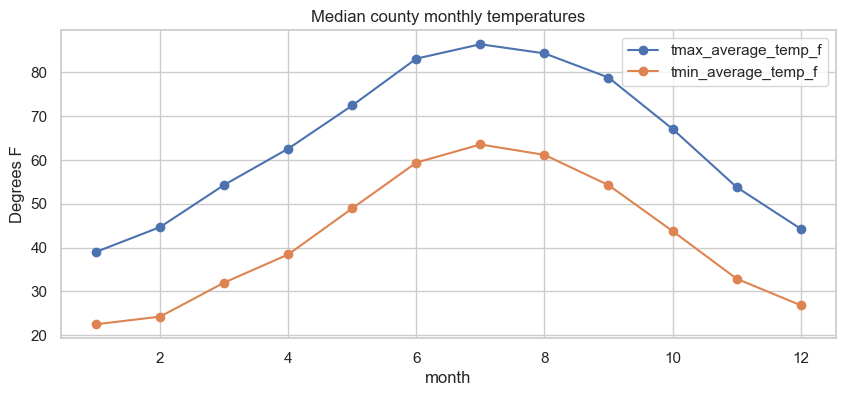

In [26]:
if not temp_records.empty:
    trend_cols = [c for c in temp_records.columns if "trend_slope" in c and c.endswith("_f")]
    display(temp_records.groupby("month")[trend_cols].median().head(12) if trend_cols else "No Fahrenheit trend columns found")
    avg_cols = [c for c in ["tmax_average_temp_f", "tmin_average_temp_f"] if c in temp_records.columns]
    if avg_cols:
        monthly = temp_records.groupby("month")[avg_cols].median()
        monthly.plot(figsize=(10, 4), marker="o", title="Median county monthly temperatures")
        plt.ylabel("Degrees F")
        plt.show()

## Nested Column: fema_disaster_declarations

In [27]:
fema_rows = []
fema_breakdown_rows = []
for _, row in df[["fips", "county_name", "state", "fema_disaster_declarations"]].dropna(subset=["fema_disaster_declarations"]).iterrows():
    value = row["fema_disaster_declarations"]
    if not isinstance(value, dict):
        continue
    years = value.get("fyDeclared", [])
    summary = value.get("summary", [])
    for year, count in zip(years, summary):
        fema_rows.append({"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "fyDeclared": year, "declarations": count})
    for incident_type, counts in value.get("breakdown", {}).items():
        for year, count in zip(years, counts):
            fema_breakdown_rows.append({"fips": row["fips"], "county_name": row["county_name"], "state": row["state"], "fyDeclared": year, "incident_type": incident_type, "declarations": count})

fema_summary = pd.DataFrame(fema_rows)
fema_breakdown = pd.DataFrame(fema_breakdown_rows)
display(fema_summary.head())
display(fema_breakdown.head())
display(completeness_report(fema_summary))
display(completeness_report(fema_breakdown))

,fips,county_name,state,fyDeclared,declarations
0,01001,Autauga County,AL,2011,1
1,01001,Autauga County,AL,2023,3
2,01001,Autauga County,AL,2024,4
3,01003,Baldwin County,AL,2008,1
4,01003,Baldwin County,AL,2009,1


,fips,county_name,state,fyDeclared,incident_type,declarations
0,01001,Autauga County,AL,2011,coastal_storm,0
1,01001,Autauga County,AL,2023,coastal_storm,0
2,01001,Autauga County,AL,2024,coastal_storm,0
3,01001,Autauga County,AL,2011,earthquake,0
4,01001,Autauga County,AL,2023,earthquake,0


,non_null_count,missing_count,missing_pct,dtype
fyDeclared,5443,0,0.0,int64
declarations,5443,0,0.0,int64


,non_null_count,missing_count,missing_pct,dtype
fyDeclared,87088,0,0.0,int64
incident_type,87088,0,0.0,object
declarations,87088,0,0.0,int64


,declarations
fyDeclared,
2005,187
2007,74
2008,661
2009,266
2010,194
2011,219
2012,63
2022,14
2023,3440


,fips,county_name,state,declarations
894,21129,Lee County,KY,46
855,21051,Clay County,KY,45
924,21189,Owsley County,KY,44
884,21109,Jackson County,KY,41
862,21065,Estill County,KY,41
931,21203,Rockcastle County,KY,40
928,21197,Powell County,KY,40
846,21033,Caldwell County,KY,37
947,21235,Whitley County,KY,36
842,21025,Breathitt County,KY,36


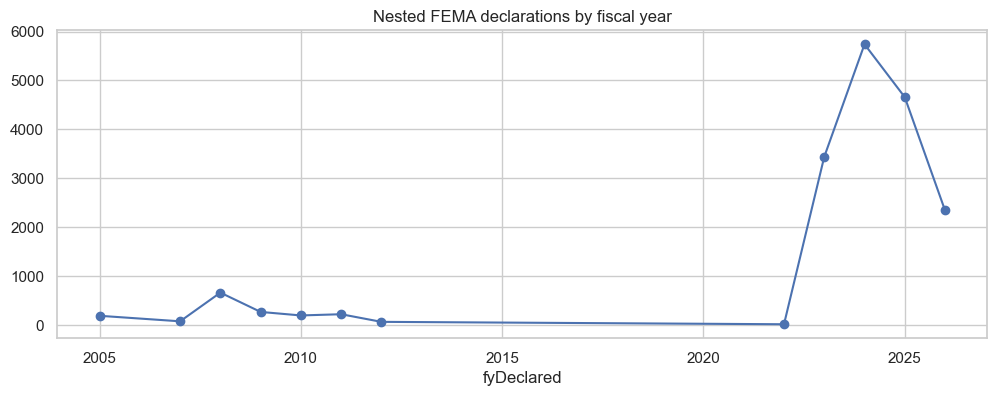

,declarations
incident_type,
severe_storm,3895
flood,3565
tornado,2270
straight_line_winds,1819
winter_storm,1474
tropical_storm,1398
hurricane,1376
mud_landslide,1089
fire,290


In [28]:
if not fema_summary.empty:
    display(fema_summary.groupby("fyDeclared")["declarations"].sum().tail(20).to_frame("declarations"))
    county_disasters = fema_summary.groupby(["fips", "county_name", "state"], as_index=False)["declarations"].sum().sort_values("declarations", ascending=False)
    display(county_disasters.head(25))
    fema_summary.groupby("fyDeclared")["declarations"].sum().plot(figsize=(12, 4), marker="o", title="Nested FEMA declarations by fiscal year")
    plt.show()

if not fema_breakdown.empty:
    display(fema_breakdown.groupby("incident_type")["declarations"].sum().sort_values(ascending=False).head(25).to_frame("declarations"))

## Nested Column: storm_events

In [29]:
storm_records = records_from_array_column("storm_events")
display(storm_records.head())
display(storm_records.shape)
display(completeness_report(storm_records).head(60))
display(nested_numeric_summary(storm_records).head(40))

,fips,county_name,state,state_id,total_damage_crops,total_damage_property,total_damage_total,total_damage_total_percentile_nationally,total_damage_total_percentile_within_state,total_damage_total_rank_nationally,total_damage_total_rank_within_state,total_deaths_direct,total_deaths_indirect,total_deaths_total,total_deaths_total_percentile_nationally,total_deaths_total_percentile_within_state,total_deaths_total_rank_nationally,total_deaths_total_rank_within_state,total_event_count,total_event_count_by_type,total_event_count_percentile_nationally,total_event_count_percentile_within_state,total_event_count_rank_nationally,total_event_count_rank_within_state,total_injuries_direct,total_injuries_indirect,total_injuries_total,total_injuries_total_percentile_nationally,total_injuries_total_percentile_within_state,total_injuries_total_rank_nationally,total_injuries_total_rank_within_state,year
0,01001,Autauga County,AL,01,0,0,0,0.0,0.001,20992,278,0,0,0,0.0,0.001,1442,52,7,"{'debris_flow': None, 'drought': None, 'dust_d...",0.393,0.375,17896,415,2,0,2,0.965,0.912,707,47,2019
1,01001,Autauga County,AL,01,0,0,0,0.0,0.001,20992,278,0,0,0,0.0,0.001,1442,52,5,"{'debris_flow': None, 'drought': None, 'dust_d...",0.268,0.248,21738,495,0,0,0,0.000,0.001,2205,119,2018
2,01001,Autauga County,AL,01,0,0,0,0.0,0.001,20992,278,0,0,0,0.0,0.001,1442,52,9,"{'debris_flow': None, 'drought': None, 'dust_d...",0.502,0.479,14679,350,0,0,0,0.000,0.001,2205,119,2025
3,01001,Autauga County,AL,01,0,0,0,0.0,0.001,20992,278,0,0,0,0.0,0.001,1442,52,3,"{'debris_flow': None, 'drought': None, 'dust_d...",0.131,0.106,26053,604,0,0,0,0.000,0.001,2205,119,2024
4,01001,Autauga County,AL,01,0,0,0,0.0,0.001,20992,278,0,0,0,0.0,0.001,1442,52,6,"{'debris_flow': None, 'drought': None, 'dust_d...",0.332,0.320,19756,455,0,0,0,0.000,0.001,2205,119,2017


(32402, 32)

,non_null_count,missing_count,missing_pct,dtype
state_id,32402,0,0.0,object
total_damage_crops,32402,0,0.0,int64
total_damage_property,32402,0,0.0,int64
total_damage_total,32402,0,0.0,int64
total_damage_total_percentile_nationally,32402,0,0.0,float64
total_damage_total_percentile_within_state,32402,0,0.0,float64
total_damage_total_rank_nationally,32402,0,0.0,int64
total_damage_total_rank_within_state,32402,0,0.0,int64
total_deaths_direct,32402,0,0.0,int64
total_deaths_indirect,32402,0,0.0,int64


,count,mean,std,min,5%,25%,50%,75%,95%,max
total_damage_total,32402.0,3.363605e+06,1.070441e+08,0.0,0.000,0.000,11000.000,106000.000,2104975.000,1.000203e+10
total_damage_property,32402.0,3.231001e+06,1.069998e+08,0.0,0.000,0.000,10000.000,100000.000,1762800.000,1.000192e+10
total_damage_crops,32402.0,1.326045e+05,2.400968e+06,0.0,0.000,0.000,0.000,0.000,10000.000,2.532500e+08
total_event_count_rank_nationally,32402.0,1.550729e+04,8.999920e+03,1.0,1536.000,7488.000,16197.000,23814.000,30478.000,3.047800e+04
total_damage_total_rank_nationally,32402.0,1.416946e+04,6.977903e+03,1.0,1636.050,8127.000,16193.000,20992.000,20992.000,2.099200e+04
total_event_count_rank_within_state,32402.0,4.908083e+02,4.347655e+02,1.0,32.000,170.000,390.000,675.000,1270.000,2.526000e+03
total_injuries_total_rank_nationally,32402.0,2.108778e+03,3.700360e+02,1.0,1144.000,2205.000,2205.000,2205.000,2205.000,2.205000e+03
total_damage_total_rank_within_state,32402.0,4.374221e+02,3.635385e+02,1.0,33.000,158.000,368.000,593.000,1338.000,1.551000e+03
total_deaths_total_rank_nationally,32402.0,1.393355e+03,2.276860e+02,1.0,1442.000,1442.000,1442.000,1442.000,1442.000,1.442000e+03
total_injuries_total_rank_within_state,32402.0,6.510931e+01,4.611036e+01,1.0,10.000,29.000,54.000,80.000,182.000,1.820000e+02


In [30]:
if not storm_records.empty:
    damage_col = "total_damage_total"
    event_col = "total_events" if "total_events" in storm_records.columns else None
    group_cols = ["event_type"] if "event_type" in storm_records.columns else []
    if group_cols and damage_col in storm_records.columns:
        display(storm_records.groupby(group_cols)[damage_col].sum().sort_values(ascending=False).head(25).to_frame("total_damage"))
    if damage_col in storm_records.columns:
        display(
            storm_records.groupby(["fips", "county_name", "state"], as_index=False)[damage_col]
            .sum()
            .sort_values(damage_col, ascending=False)
            .head(25)
        )
    if event_col:
        display(storm_records.groupby(group_cols)[event_col].sum().sort_values(ascending=False).head(25).to_frame("events") if group_cols else storm_records[event_col].describe())

,fips,county_name,state,total_damage_total
2597,48201,Harris County,TX,10365229500
2580,48167,Galveston County,TX,10004598510
2575,48157,Fort Bend County,TX,8008484300
2666,48339,Montgomery County,TX,7200654900
2553,48113,Dallas County,TX,3401943000
2619,48245,Jefferson County,TX,3309465000
1103,22033,East Baton Rouge Parish,LA,2408695500
249,08059,Jefferson County,CO,2300130000
2539,48085,Collin County,TX,2196248750
2516,48039,Brazoria County,TX,2006999500
